In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


In [6]:
diabetes_df = pd.read_csv('../data/raw/diabetes.csv')
heart_df = pd.read_csv('../data/raw/heart_cleveland_upload.csv')

liver_cols = [
    'Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
    'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
    'Aspartate_Aminotransferase', 'Total_Protiens',
    'Albumin', 'Albumin_Globulin_Ratio', 'Dataset'
]
liver_df = pd.read_csv('../data/raw/indian_liver_patient.csv', names=liver_cols)

print(f'Diabetes shape:      {diabetes_df.shape}')
print(f'Heart Disease shape: {heart_df.shape}')
print(f'Liver Disease shape: {liver_df.shape}')

Diabetes shape:      (768, 9)
Heart Disease shape: (303, 14)
Liver Disease shape: (583, 11)


In [7]:
# Check what's in the heart file
heart_df = pd.read_csv('../data/raw/heart_cleveland_upload.csv')
print(heart_df.head())
print(heart_df.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
(303, 14)


In [8]:
heart_df = pd.read_csv('../data/raw/heart_cleveland_upload.csv')
print(heart_df.head())
print(heart_df.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
(303, 14)


In [9]:
print('=' * 60)
print('DIABETES — First look')
print('=' * 60)
print(diabetes_df.head())
print('\nMissing values:')
print(diabetes_df.isnull().sum())

print('\n' + '=' * 60)
print('HEART DISEASE — First look')
print('=' * 60)
print(heart_df.head())
print('\nMissing values:')
print(heart_df.isnull().sum())

print('\n' + '=' * 60)
print('LIVER DISEASE — First look')
print('=' * 60)
print(liver_df.head())
print('\nMissing values:')
print(liver_df.isnull().sum())

DIABETES — First look
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                 

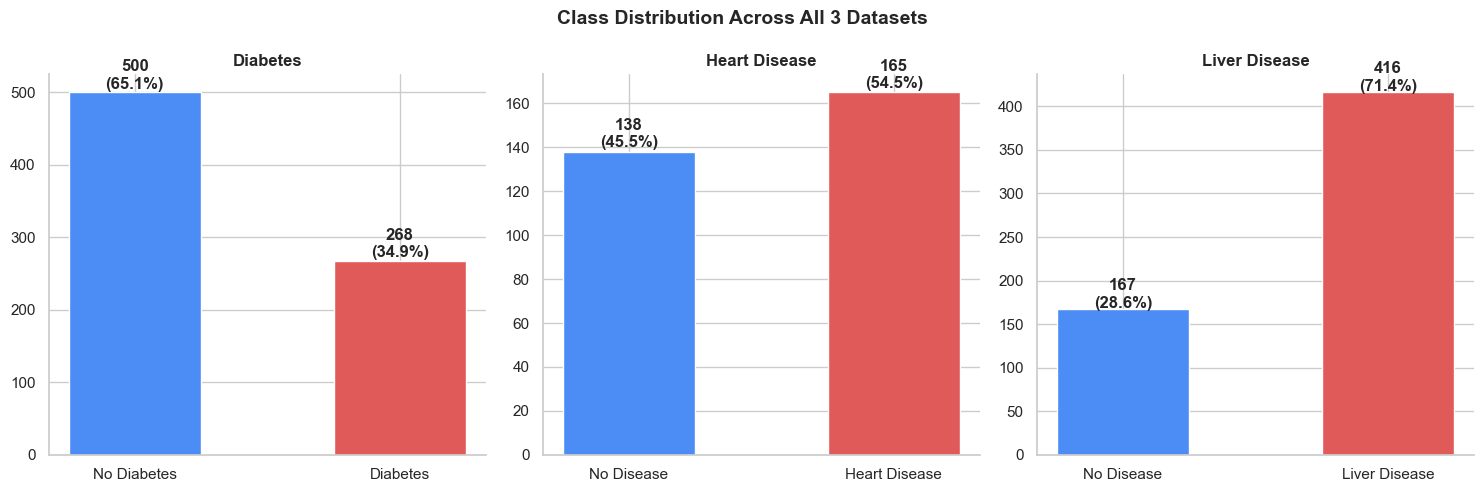

Chart saved to assets/class_distribution.png ✅


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Diabetes
counts0 = diabetes_df['Outcome'].value_counts().sort_index()
axes[0].bar(['No Diabetes', 'Diabetes'], counts0.values, color=['#4C8CF5', '#E05A5A'], width=0.5, edgecolor='white')
for i, v in enumerate(counts0.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(diabetes_df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Diabetes', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

# Heart Disease
counts1 = heart_df['target'].value_counts().sort_index()
axes[1].bar(['No Disease', 'Heart Disease'], counts1.values, color=['#4C8CF5', '#E05A5A'], width=0.5, edgecolor='white')
for i, v in enumerate(counts1.values):
    axes[1].text(i, v + 2, f'{v}\n({v/len(heart_df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Heart Disease', fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

# Liver Disease
liver_df['Target'] = liver_df['Dataset'].map({1: 1, 2: 0})
counts2 = liver_df['Target'].value_counts().sort_index()
axes[2].bar(['No Disease', 'Liver Disease'], counts2.values, color=['#4C8CF5', '#E05A5A'], width=0.5, edgecolor='white')
for i, v in enumerate(counts2.values):
    axes[2].text(i, v + 2, f'{v}\n({v/len(liver_df)*100:.1f}%)', ha='center', fontweight='bold')
axes[2].set_title('Liver Disease', fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Class Distribution Across All 3 Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to assets/class_distribution.png ✅')

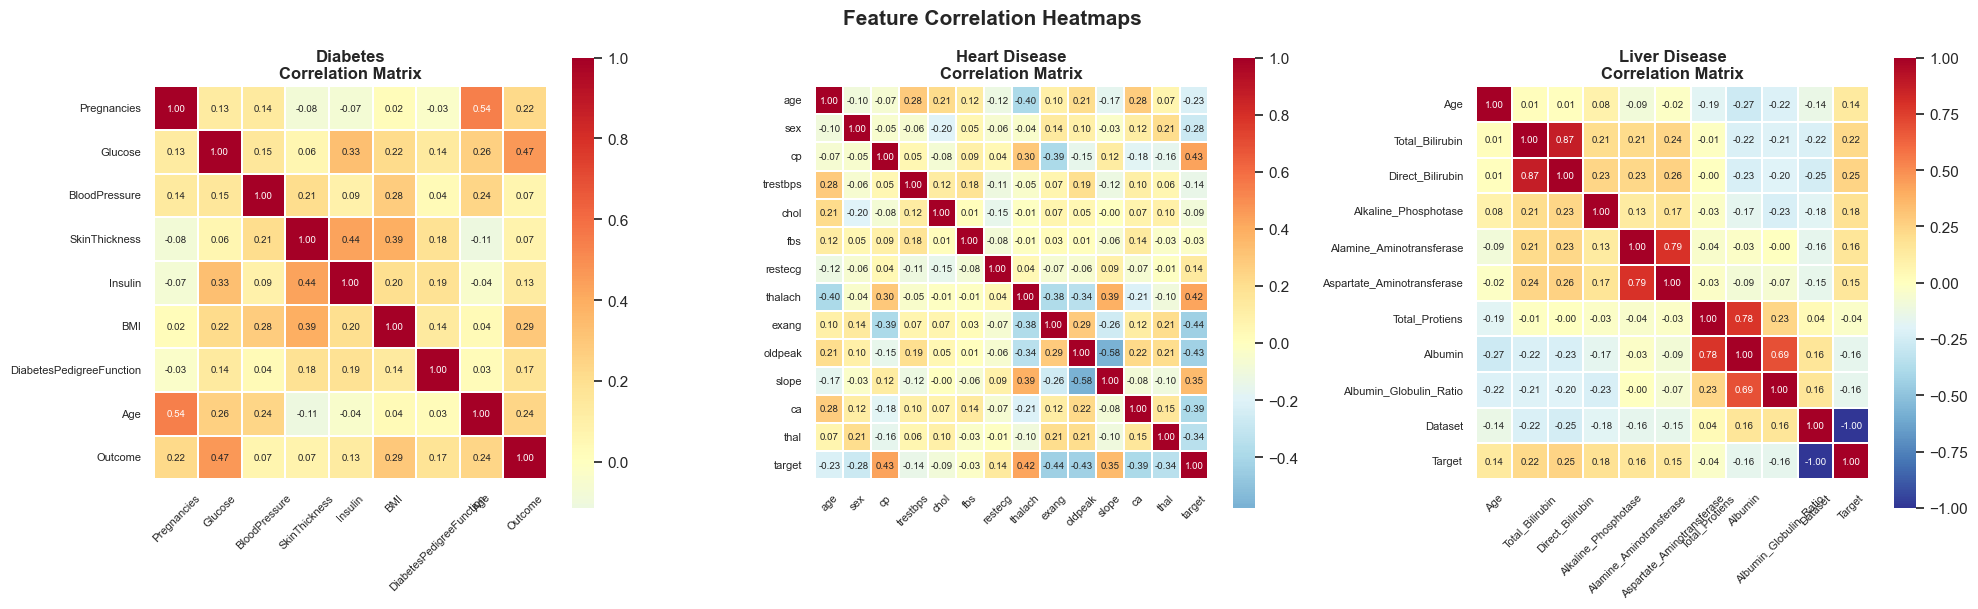

Heatmaps saved ✅


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Diabetes
sns.heatmap(diabetes_df.corr(), ax=axes[0], annot=True, fmt='.2f',
            annot_kws={'size': 7}, cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.3)
axes[0].set_title('Diabetes\nCorrelation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Heart Disease
sns.heatmap(heart_df.corr(), ax=axes[1], annot=True, fmt='.2f',
            annot_kws={'size': 7}, cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.3)
axes[1].set_title('Heart Disease\nCorrelation Matrix', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)

# Liver Disease
liver_numeric = liver_df.select_dtypes(include=np.number).columns.tolist()
sns.heatmap(liver_df[liver_numeric].corr(), ax=axes[2], annot=True, fmt='.2f',
            annot_kws={'size': 7}, cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.3)
axes[2].set_title('Liver Disease\nCorrelation Matrix', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=8)
axes[2].tick_params(axis='y', labelsize=8)

plt.suptitle('Feature Correlation Heatmaps', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/correlation_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmaps saved ✅')

In [23]:
print('=' * 60)
print('  EDA SUMMARY — KEY FINDINGS')
print('=' * 60)

# Diabetes
diab_pos = diabetes_df['Outcome'].value_counts(normalize=True)[1] * 100
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = (diabetes_df[zero_cols] == 0).sum()
print(f"""
📊 DIABETES
   Shape       : {diabetes_df.shape}
   Positive    : {diab_pos:.1f}% have diabetes
   Zero-as-NaN : {dict(zero_counts[zero_counts > 0])}
   → Action    : Impute zeros with median
""")

# Heart
heart_pos = heart_df['target'].value_counts(normalize=True)[1] * 100
print(f"""❤️  HEART DISEASE
   Shape       : {heart_df.shape}
   Positive    : {heart_pos:.1f}% have heart disease
   Missing vals: {heart_df.isnull().sum().sum()} nulls
   → Action    : Encode categorical features
""")

# Liver
liver_pos = liver_df['Target'].value_counts(normalize=True)[1] * 100
liver_missing = liver_df.isnull().sum().sum()
print(f"""🫀 LIVER DISEASE
   Shape       : {liver_df.shape}
   Positive    : {liver_pos:.1f}% have liver disease
   Missing vals: {liver_missing} nulls
   → Action    : Encode Gender, impute missing values
""")

  EDA SUMMARY — KEY FINDINGS

📊 DIABETES
   Shape       : (768, 9)
   Positive    : 34.9% have diabetes
   Zero-as-NaN : {'Glucose': np.int64(5), 'BloodPressure': np.int64(35), 'SkinThickness': np.int64(227), 'Insulin': np.int64(374), 'BMI': np.int64(11)}
   → Action    : Impute zeros with median

❤️  HEART DISEASE
   Shape       : (303, 14)
   Positive    : 54.5% have heart disease
   Missing vals: 0 nulls
   → Action    : Encode categorical features

🫀 LIVER DISEASE
   Shape       : (583, 11)
   Positive    : 71.4% have liver disease
   Missing vals: 4 nulls
   → Action    : Encode Gender, impute missing values



In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20

print('Setup complete ✅')
print(f'Train/Test split: 80/20')

Setup complete ✅
Train/Test split: 80/20


In [16]:
diabetes_df = pd.read_csv('../data/raw/diabetes.csv')
heart_df = pd.read_csv('../data/raw/heart_cleveland_upload.csv')

liver_cols = [
    'Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
    'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
    'Aspartate_Aminotransferase', 'Total_Protiens',
    'Albumin', 'Albumin_Globulin_Ratio', 'Dataset'
]
liver_df = pd.read_csv('../data/raw/indian_liver_patient.csv', names=liver_cols)
liver_df['Target'] = liver_df['Dataset'].map({1: 1, 2: 0})
liver_df.drop(columns=['Dataset'], inplace=True)

print(f'✅ Diabetes  : {diabetes_df.shape}')
print(f'✅ Heart     : {heart_df.shape}')
print(f'✅ Liver     : {liver_df.shape}')

✅ Diabetes  : (768, 9)
✅ Heart     : (303, 14)
✅ Liver     : (583, 11)


In [17]:
print('── DIABETES PREPROCESSING ──')
df = diabetes_df.copy()

# Replace impossible zeros with NaN
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)

# Impute with median
imputer = SimpleImputer(strategy='median')
df[zero_cols] = imputer.fit_transform(df[zero_cols])

# Cap outliers using IQR
feature_cols = [c for c in df.columns if c != 'Outcome']
for col in feature_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Split and scale
X = df[feature_cols]
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
scaler_diabetes = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_diabetes.fit_transform(X_train), columns=feature_cols)
X_test_scaled  = pd.DataFrame(scaler_diabetes.transform(X_test), columns=feature_cols)

# Save
X_train_scaled.assign(Outcome=y_train.values).to_csv('../data/processed/diabetes_train.csv', index=False)
X_test_scaled.assign(Outcome=y_test.values).to_csv('../data/processed/diabetes_test.csv', index=False)
joblib.dump(scaler_diabetes, '../models/scaler_diabetes.pkl')
joblib.dump(feature_cols, '../models/features_diabetes.pkl')

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')
print(f'Class balance: {y_train.value_counts().to_dict()}')
print('✅ Diabetes preprocessing done!')

── DIABETES PREPROCESSING ──
Train: (614, 8) | Test: (154, 8)
Class balance: {0: 400, 1: 214}
✅ Diabetes preprocessing done!


In [18]:
print('── HEART DISEASE PREPROCESSING ──')
df = heart_df.copy()

# Handle any missing values
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
if df.isnull().sum().sum() > 0:
    imputer = SimpleImputer(strategy='median')
    df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Cap outliers
target_col = 'target'
feature_cols_heart = [c for c in df.columns if c != target_col]
for col in feature_cols_heart:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Split and scale
X = df[feature_cols_heart]
y = df[target_col].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
scaler_heart = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_heart.fit_transform(X_train), columns=feature_cols_heart)
X_test_scaled  = pd.DataFrame(scaler_heart.transform(X_test), columns=feature_cols_heart)

# Save
X_train_scaled.assign(target=y_train.values).to_csv('../data/processed/heart_train.csv', index=False)
X_test_scaled.assign(target=y_test.values).to_csv('../data/processed/heart_test.csv', index=False)
joblib.dump(scaler_heart, '../models/scaler_heart.pkl')
joblib.dump(feature_cols_heart, '../models/features_heart.pkl')

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')
print(f'Class balance: {y_train.value_counts().to_dict()}')
print('✅ Heart preprocessing done!')

── HEART DISEASE PREPROCESSING ──
Train: (242, 13) | Test: (61, 13)
Class balance: {1: 132, 0: 110}
✅ Heart preprocessing done!


In [19]:
print('── LIVER DISEASE PREPROCESSING ──')
df = liver_df.copy()

# Encode Gender (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print(f'Gender encoded: {dict(enumerate(le.classes_))}')

# Impute missing values
feature_cols_liver = [c for c in df.columns if c != 'Target']
imputer = SimpleImputer(strategy='median')
df[feature_cols_liver] = imputer.fit_transform(df[feature_cols_liver])

# Cap outliers
for col in feature_cols_liver:
    if col == 'Gender':
        continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Split and scale
X = df[feature_cols_liver]
y = df['Target'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
scaler_liver = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_liver.fit_transform(X_train), columns=feature_cols_liver)
X_test_scaled  = pd.DataFrame(scaler_liver.transform(X_test), columns=feature_cols_liver)

# Save
X_train_scaled.assign(Target=y_train.values).to_csv('../data/processed/liver_train.csv', index=False)
X_test_scaled.assign(Target=y_test.values).to_csv('../data/processed/liver_test.csv', index=False)
joblib.dump(scaler_liver, '../models/scaler_liver.pkl')
joblib.dump(feature_cols_liver, '../models/features_liver.pkl')

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')
print(f'Class balance: {y_train.value_counts().to_dict()}')
print('✅ Liver preprocessing done!')

── LIVER DISEASE PREPROCESSING ──
Gender encoded: {0: 'Female', 1: 'Male'}
Train: (466, 10) | Test: (117, 10)
Class balance: {1: 333, 0: 133}
✅ Liver preprocessing done!


In [24]:
import glob

processed_files = sorted(glob.glob('../data/processed/*.csv'))
model_files = sorted(glob.glob('../models/*.pkl'))

print('📁 data/processed/')
for f in processed_files:
    df_check = pd.read_csv(f)
    print(f'   ✅ {os.path.basename(f):35s} → shape {df_check.shape}')

print()
print('📁 models/')
for f in model_files:
    size_kb = os.path.getsize(f) / 1024
    print(f'   ✅ {os.path.basename(f):35s} → {size_kb:.1f} KB')

print()

📁 data/processed/
   ✅ diabetes_test.csv                   → shape (154, 9)
   ✅ diabetes_train.csv                  → shape (614, 9)
   ✅ heart_test.csv                      → shape (61, 14)
   ✅ heart_train.csv                     → shape (242, 14)
   ✅ liver_test.csv                      → shape (117, 11)
   ✅ liver_train.csv                     → shape (466, 11)

📁 models/
   ✅ features_diabetes.pkl               → 0.1 KB
   ✅ features_heart.pkl                  → 0.1 KB
   ✅ features_liver.pkl                  → 0.2 KB
   ✅ scaler_diabetes.pkl                 → 1.1 KB
   ✅ scaler_heart.pkl                    → 1.2 KB
   ✅ scaler_liver.pkl                    → 1.3 KB

